### Import Libraries


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
from TextPreprocessor import TextPreprocessor
from sklearn.model_selection import train_test_split
import json
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



### Preprocess Datasets
saves a csv with stop words and splits the data


In [183]:
dataset = pd.read_csv("../data/imdb_dataset.csv")
preprocessor = TextPreprocessor(True, True, True)

dataset = preprocessor.process(dataset, textcol="review", drop_original=True)


if dataset['sentiment'].dtype == 'object':
    dataset['sentiment'] = dataset['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    dataset["cleaned_review"].values, dataset["sentiment"].values,
    test_size=0.2, random_state=42, stratify=dataset["sentiment"].values
)
dataset.to_csv("../data/imdb_cleaned_with_stop.csv", index=False)

### Set Tokenizer Parameters


In [184]:
vocab_size = 20000
max_length = 300
oov_token = "<OOV>"

### Tokenizes and Saves it 


In [185]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post', truncating='post')

tok_json = tokenizer.to_json()
with open('../models/tokenizer.json', 'w') as json_file:
    json_file.write(tok_json)

    

### Import Keras Models and Layers


In [186]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, GlobalMaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Bidirectional
from tensorflow.keras import regularizers

### MLP Model

In [199]:
mlp_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length, mask_zero=True),
    SpatialDropout1D(0.2),                   
    GlobalAveragePooling1D(),                  
    Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
    ])

/home/jason/ann/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### LTSM Model

In [188]:
ltsm_model = Sequential([
        Embedding(vocab_size, 128, input_length=max_length, mask_zero=True),
        SpatialDropout1D(0.2),                                
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        GlobalMaxPooling1D(),                                 
        Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

### CNN Model

In [ ]:
cnn_model = Sequential([
         Embedding(vocab_size, 128, input_length=max_length, mask_zero=True),
        SpatialDropout1D(0.2),
        Conv1D(filters=128, kernel_size=5, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=5, activation="relu", padding="same"),
        GlobalMaxPooling1D(),                      # robust head for n-grams
        Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ])

### Compile the Models and Summary

In [200]:
mlp_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
ltsm_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
cnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
mlp_model.summary()
ltsm_model.summary()
cnn_model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_38 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_28     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_36 (Embedding)        │ (32, 300, 128)         │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (32, 296, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (32, 148, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (32, 144, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_26     │ (32, 128)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,724,225 (10.39 MB)

 Trainable params: 2,724,225 (10.39 MB)

 Non-trainable params: 0 (0.00 B)

### Train with Callbacks 
early stoppping and best checkpoint

In [191]:
ckpt_path = "../models/nn_models/best.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

### Train MLP 

In [201]:
mlp_history = mlp_model.fit(
    X_train_padded, y_train, 
    validation_data=(X_test_padded, y_test), 
    epochs=10, 
    batch_size=32, 
    callbacks=callbacks, 
    verbose=1
    )

Epoch 1/10


2025-12-09 17:24:55.726222: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-09 17:24:55.726419: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-09 17:24:55.726429: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-09 17:24:56.257438: I external/l

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8708 - loss: 0.3167 - val_accuracy: 0.9004 - val_loss: 0.2536
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9359 - loss: 0.1843 - val_accuracy: 0.8991 - val_loss: 0.2618


### Train LTSM


In [194]:
ltsm_history = ltsm_model.fit(
    X_train_padded, y_train, 
    validation_data=(X_test_padded, y_test), 
    epochs=10, 
    batch_size=32, 
    callbacks=callbacks, 
    verbose=1
    )

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2299s 2s/step - accuracy: 0.8692 - loss: 0.3220 - val_accuracy: 0.8967 - val_loss: 0.2639
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2370s 2s/step - accuracy: 0.9280 - loss: 0.1972 - val_accuracy: 0.8993 - val_loss: 0.2529


### Train CNN

In [195]:
cnn_history = cnn_model.fit(
    X_train_padded, y_train, 
    validation_data=(X_test_padded, y_test), 
    epochs=10, 
    batch_size=32, 
    callbacks=callbacks, 
    verbose=1
    )

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8540 - loss: 0.3399 - val_accuracy: 0.8997 - val_loss: 0.2588
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9340 - loss: 0.1799 - val_accuracy: 0.8977 - val_loss: 0.2563


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0      0.901     0.899     0.900      5000
           1      0.899     0.902     0.901      5000

    accuracy                          0.900     10000
   macro avg      0.900     0.900     0.900     10000
weighted avg      0.900     0.900     0.900     10000



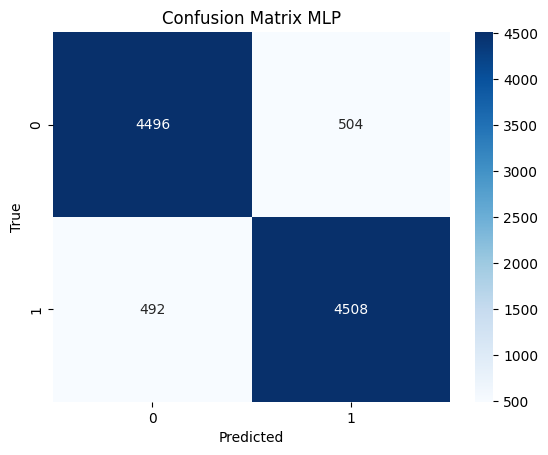

In [202]:
y_prob = mlp_model.predict(X_test_padded).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix MLP")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()


/home/jason/ann/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 218s 693ms/step
              precision    recall  f1-score   support

           0      0.879     0.920     0.899      5000
           1      0.916     0.873     0.894      5000

    accuracy                          0.897     10000
   macro avg      0.898     0.897     0.897     10000
weighted avg      0.898     0.897     0.897     10000



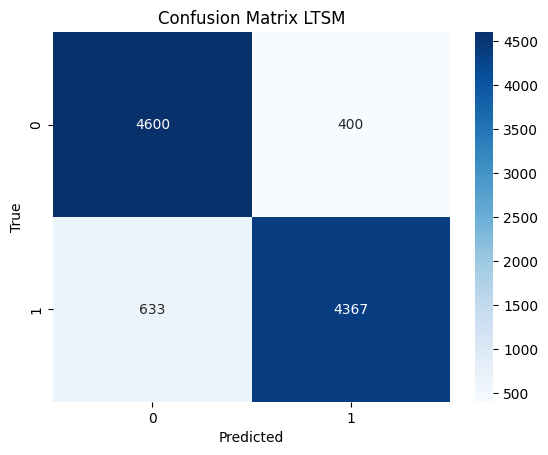

In [197]:
y_prob = ltsm_model.predict(X_test_padded).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix LTSM")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0      0.891     0.913     0.902      5000
           1      0.911     0.888     0.899      5000

    accuracy                          0.901     10000
   macro avg      0.901     0.901     0.901     10000
weighted avg      0.901     0.901     0.901     10000



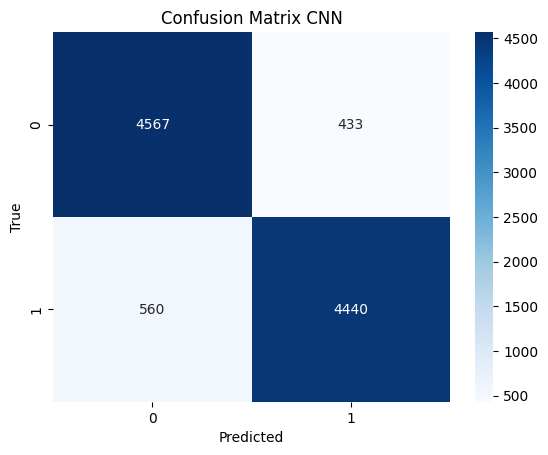

In [ ]:
y_prob = cnn_model.predict(X_test_padded).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix CNN")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()


In [ ]:
def predict_review(text: str): 
    ptext = preprocessor.clean(text)
    seq = tokenizer.texts_to_sequences([ptext])
    pad = pad_sequences(seq, maxlen=max_length, padding="post", truncating="post")
    p = float(cnn_model.predict(pad)[0][0])
    label = "Positive" if p>=0.5 else "Negative"
    return label, p

predict_review("The movie is not great")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


('Positive', 0.5279200077056885)